<a href="https://colab.research.google.com/github/partha-pkp/data-mining-drug-discovery/blob/main/partha/6380_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Structure of Notebook**
  
1. `Feature Selection`
 - CFS --> bi-directional search model with 17 features  
2. `Bagging and MLP` model training  
  - Bagging without feature selection (fs)  
  - Bagging with fs  
  - MLP without fs  
  - MLP with fs  
3. `Computational Screening`  
  - Table with 21 compound comparision


**CSVs to be uploaded to colab runtime**
- input_data.csv
- input_data_no_smiles.csv
- list_of_compounds_for_computational_screening.csv
- ResearchPaperPreds.csv


# Feature Selection

In [3]:
# install first in notebook/terminal:
!pip install python-weka-wrapper3

import weka.core.jvm as jvm

jvm.start(packages=True)

# later, when finished:
# jvm.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 138.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 43.5 MB/s eta 0:00:00
  Created wheel for python-weka-wrapper3: filename=python_weka_wrapper3-0.3.3-py3-none-any.whl size=14961686 sha256=8101915a682cae1857261c7dd3d2706c972ef639333a3822783d630f2befa315
  Stored in directory: /root/.cache/pip/wheels/ed/c6/0d/0eb790fcd08c0412658cbb117a6b7a135f9528b9557abd1057
  Created wheel for configurable_objects: filename=configurable_objects-0.0.1-py3-none-any.whl size=4694 sha256=6190776b44bfc9ee6601a4db687eb54f894002325f917887ee01f1de2264c167
  Stored in directory: /root/.cache/pip/wheels/c7/58/b0/fd2ffbc9a6e370df1ebad34703b46a1c5dd33aa734d407e909
  Created wheel for simple_data_flow: filename=simple_data_flow-0.0.1-py3-none-any.whl size=19058 sha2

DEBUG:weka.core.jvm:Adding bundled jars
DEBUG:weka.core.jvm:Classpath=['/usr/local/lib/python3.12/dist-packages/weka/lib/arpack_combined.jar', '/usr/local/lib/python3.12/dist-packages/weka/lib/weka.jar', '/usr/local/lib/python3.12/dist-packages/weka/lib/core.jar', '/usr/local/lib/python3.12/dist-packages/weka/lib/mtj.jar', '/usr/local/lib/python3.12/dist-packages/weka/lib/python-weka-wrapper.jar']
DEBUG:weka.core.jvm:MaxHeapSize=default
DEBUG:weka.core.jvm:Package support enabled


## Normalize data

In [7]:
# pwd
! ls

input_data.csv					   ResearchPaperPreds.csv
input_data_no_smiles.csv			   sample_data
list_of_compounds_for_computational_screening.csv


In [8]:
import weka.core.converters as converters
from weka.filters import Filter

data = converters.load_any_file("input_data_no_smiles.csv", class_index="last")


In [9]:
from weka.filters import Filter

norm = Filter(classname="weka.filters.unsupervised.attribute.Normalize")
norm.inputformat(data)
data_norm = norm.filter(data)

# print(data_norm)

## CFS

In [10]:
from weka.attribute_selection import ASSearch, ASEvaluation, AttributeSelection

search = ASSearch(
    classname="weka.attributeSelection.BestFirst",
    options=["-D", "2", "-N", "5"]
)

evaluator = ASEvaluation(
    classname="weka.attributeSelection.CfsSubsetEval",
    options=["-P", "1", "-E", "1"]
)

attsel = AttributeSelection()
attsel.search(search)
attsel.evaluator(evaluator)
attsel.crossvalidation(True)
attsel.folds(10)
attsel.seed(1)
attsel.select_attributes(data_norm)

# IMPORTANT: call this first
# cv_text = attsel.cv_results
# print(cv_text)

# now this works
# print(attsel.subset_results)
print(attsel.results_string)



=== Attribute Selection on all input data ===

Search Method:
	Best first.
	Start set: no attributes
	Search direction: bi-directional
	Stale search after 5 node expansions
	Total number of subsets evaluated: 5200
	Merit of best subset found:    0.186

Attribute Subset Evaluator (supervised, Class (numeric): 201 senolytic):
	CFS Subset Evaluator
	Including locally predictive attributes

Selected attributes: 19,23,63,78,79,81,93,115,129,138,153,169,189,192,193,195,200 : 17
                     EState_VSA3
                     EState_VSA7
                     NumSaturatedCarbocycles
                     PEOE_VSA7
                     PEOE_VSA8
                     RingCount
                     SlogP_VSA10
                     fr_Al_COO
                     fr_Imine
                     fr_aldehyde
                     fr_dihydropyridine
                     fr_lactone
                     fr_quatN
                     fr_sulfone
                     fr_term_acetylene
                 

D=0 (direction of search --> backward)

=== Attribute Selection on all input data ===

Search Method:
	Best first.
	Search direction: backward
	Stale search after 5 node expansions
	Total number of subsets evaluated: 19997
	Merit of best subset found:    0.186

Attribute Subset Evaluator (supervised, Class (numeric): 201 senolytic):
	CFS Subset Evaluator
	Including locally predictive attributes

Selected attributes: 19,23,63,78,79,81,115,129,138,140,147,169,174,189,192,193,195,200 : 18

EState_VSA3
EState_VSA7
NumSaturatedCarbocycles
PEOE_VSA7
PEOE_VSA8
RingCount
fr_Al_COO
fr_Imine
fr_aldehyde
fr_alkyl_halide
fr_azo
fr_lactone
fr_nitro_arom
fr_quatN
fr_sulfone
fr_term_acetylene
fr_thiazole
qed




-------------- D=1 (direction of search--> forward) ---------------------------

=== Attribute Selection on all input data ===

Search Method:
	Best first.
	Start set: no attributes
	Search direction: forward
	Stale search after 5 node expansions
	Total number of subsets evaluated: 4530
	Merit of best subset found:    0.186

Attribute Subset Evaluator (supervised, Class (numeric): 201 senolytic):
	CFS Subset Evaluator
	Including locally predictive attributes

Selected attributes: 13,19,23,47,63,78,79,81,93,115,129,138,153,169,189,192,193,195,200 : 19

Chi4n
EState_VSA3
EState_VSA7
MolLogP
NumSaturatedCarbocycles
PEOE_VSA7
PEOE_VSA8
RingCount
SlogP_VSA10
fr_Al_COO
fr_Imine
fr_aldehyde
fr_dihydropyridine
fr_lactone
fr_quatN
fr_sulfone
fr_term_acetylene
fr_thiazole
qed





------------------- D=2 (direction of search--> bidirection) -------------------------------

=== Attribute Selection on all input data ===

Search Method:
	Best first.
	Start set: no attributes
	Search direction: bi-directional
	Stale search after 5 node expansions
	Total number of subsets evaluated: 5200
	Merit of best subset found:    0.186

Attribute Subset Evaluator (supervised, Class (numeric): 201 senolytic):
	CFS Subset Evaluator
	Including locally predictive attributes

Selected attributes: 19,23,63,78,79,81,93,115,129,138,153,169,189,192,193,195,200 : 17

EState_VSA3
EState_VSA7
NumSaturatedCarbocycles
PEOE_VSA7
PEOE_VSA8
RingCount
SlogP_VSA10
fr_Al_COO
fr_Imine
fr_aldehyde
fr_dihydropyridine
fr_lactone
fr_quatN
fr_sulfone
fr_term_acetylene
fr_thiazole
qed

--------------chose results from `bi-directional` search---------

### convert WEKA normalized data to pandas

In [11]:
import weka.core.converters as converters
import pandas as pd

converters.save_any_file(data_norm, "/content/data_norm.csv")
df_norm = pd.read_csv("/content/data_norm.csv")

print(type(df_norm))
print(df_norm.shape)
df_norm.head()

<class 'pandas.core.frame.DataFrame'>
(4866, 201)


,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed,senolytic
0,0.437663,0.073591,0.059606,0.049548,0.041309,0.067316,0.055618,0.055231,0.051299,0.046692,...,0,0,0,0.0,0,0.0,0.000000,0.0,0.450908,0
1,0.366771,0.037444,0.065580,0.050203,0.041970,0.064501,0.054116,0.053728,0.049837,0.045362,...,0,0,0,0.0,0,0.0,0.000000,0.5,0.338417,0
2,0.425273,0.070462,0.082200,0.064425,0.076981,0.077120,0.059804,0.110018,0.054940,0.114623,...,0,0,0,0.0,0,0.0,0.000000,0.0,0.666464,0
3,0.527412,0.020940,0.055468,0.052024,0.043807,0.047862,0.046402,0.046011,0.046628,0.042441,...,0,0,0,0.0,0,0.0,0.000000,0.0,0.256755,0
4,0.142840,0.361539,0.470540,0.501223,0.496900,0.494134,0.492997,0.492789,0.470685,0.428419,...,0,0,0,0.0,0,0.0,0.137931,0.0,0.031688,0


In [12]:
selected_features = [
    "EState_VSA3",
    "EState_VSA7",
    "NumSaturatedCarbocycles",
    "PEOE_VSA7",
    "PEOE_VSA8",
    "RingCount",
    "SlogP_VSA10",
    "fr_Al_COO",
    "fr_Imine",
    "fr_aldehyde",
    "fr_dihydropyridine",
    "fr_lactone",
    "fr_quatN",
    "fr_sulfone",
    "fr_term_acetylene",
    "fr_thiazole",
    "qed"
]

df_selected = df_norm[selected_features + ["senolytic"]].copy()

print(df_selected.shape)
df_selected.head()

(4866, 18)


,EState_VSA3,EState_VSA7,NumSaturatedCarbocycles,PEOE_VSA7,PEOE_VSA8,RingCount,SlogP_VSA10,fr_Al_COO,fr_Imine,fr_aldehyde,fr_dihydropyridine,fr_lactone,fr_quatN,fr_sulfone,fr_term_acetylene,fr_thiazole,qed,senolytic
0,0.046545,0.000000,0.0,0.000000,0.000000,0.1250,0.079697,0.0,0.0,0.0,0,0.0,0.000000,0,0,0.0,0.450908,0
1,0.000000,0.080230,0.0,0.000000,0.000000,0.0625,0.128476,0.0,0.0,0.0,0,0.0,0.000000,0,0,0.0,0.338417,0
2,0.093440,0.000000,0.0,0.000000,0.057266,0.0625,0.068753,0.0,0.0,0.0,0,0.0,0.000000,0,0,0.0,0.666464,0
3,0.000000,0.000000,0.0,0.000000,0.116581,0.0000,0.000000,0.0,0.0,0.0,0,0.0,0.000000,0,0,0.0,0.256755,0
4,0.881489,0.183083,0.0,0.439082,0.304453,0.3750,0.000000,0.0,0.0,0.0,0,0.0,0.142857,0,0,0.0,0.031688,0


Normalised dataset with all 200 features -  df_norm  
Selected features - df_selected

# Bagging and MLP

## Pre-processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from packaging.version import parse as vparse

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    PrecisionRecallDisplay
)

print("sklearn version:", sklearn.__version__)

sklearn version: 1.8.0


In [2]:
if vparse(sklearn.__version__) < vparse("1.7"):
    raise RuntimeError(
        "Your sklearn is too old for MLPClassifier(sample_weight=...). "
        "Upgrade sklearn or tell me and I'll give you a fallback."
    )

In [3]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 89.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import sklearn
print(sklearn.__version__)

1.8.0


prepaing datasets...

extra cleaning for weka datasets

In [13]:
import numpy as np
import pandas as pd

target_col = "senolytic"

def clean_weka_export(df, target_col="senolytic"):
    df = df.copy()

    # WEKA missing values
    df = df.replace("?", np.nan)

    # convert target to numeric
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

    # convert all feature columns to numeric
    feature_cols = [c for c in df.columns if c != target_col]
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # remove rows with missing target
    df = df.dropna(subset=[target_col]).copy()
    df[target_col] = df[target_col].astype(int)

    return df

In [14]:
df_norm = clean_weka_export(df_norm, target_col="senolytic")
df_selected = clean_weka_export(df_selected, target_col="senolytic")

print(df_norm.shape)
print(df_selected.shape)

print(df_norm.dtypes.head())
print(df_selected.dtypes.head())

(4866, 201)
(4866, 18)
BalabanJ    float64
BertzCT     float64
Chi0        float64
Chi0n       float64
Chi0v       float64
dtype: object
EState_VSA3                float64
EState_VSA7                float64
NumSaturatedCarbocycles    float64
PEOE_VSA7                  float64
PEOE_VSA8                  float64
dtype: object


In [15]:
target_col = "senolytic"

X_all = df_norm.drop(columns=[target_col]).copy()
X_fs = df_selected.drop(columns=[target_col]).copy()
y = df_norm[target_col].copy()

print("All features:", X_all.shape)
print("Selected features:", X_fs.shape)
print(y.value_counts())

All features: (4866, 200)
Selected features: (4866, 17)
senolytic
0    4763
1     103
Name: count, dtype: int64


one train/test split used for both datasets

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_all_train = X_all.iloc[train_idx]
X_all_test  = X_all.iloc[test_idx]

X_fs_train = X_fs.iloc[train_idx]
X_fs_test  = X_fs.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

helper: choose threshold with recall >= 0.50

In [17]:
def best_threshold_for_min_recall(y_true, y_prob, min_recall=0.50):
    best_t = None
    best_p = -1
    best_r = -1

    for t in np.linspace(0, 1, 201):
        y_pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)

        if r >= min_recall and p > best_p:
            best_t = t
            best_p = p
            best_r = r

    return best_t, best_p, best_r

helper: build models

In [18]:
def make_bagging_model(n_estimators=100, max_depth=None, min_samples_leaf=1):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ),
            n_estimators=n_estimators,
            bootstrap=True,
            max_samples=1.0,
            random_state=42,
            n_jobs=-1
        ))
    ])


def make_mlp_model(hidden_layer_sizes=(500,), alpha=0.0001, learning_rate_init=0.001):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            max_iter=400,
            early_stopping=True,
            random_state=42
        ))
    ])

helper: run one weighted experiment

In [19]:
def run_one_experiment(model, X_train, X_test, y_train, y_test, pos_weight, label):
    sample_w = compute_sample_weight(
        class_weight={0: 1, 1: pos_weight},
        y=y_train
    )

    model.fit(X_train, y_train, model__sample_weight=sample_w)

    y_prob = model.predict_proba(X_test)[:, 1]

    best_t, best_p, best_r = best_threshold_for_min_recall(
        y_test, y_prob, min_recall=0.50
    )

    ap = average_precision_score(y_test, y_prob)

    result = {
        "label": label,
        "pos_weight": pos_weight,
        "best_threshold": best_t,
        "precision_at_target": best_p,
        "recall_at_target": best_r,
        "average_precision": ap,
        "y_prob": y_prob,
        "model": model
    }

    return result

## Bagging sweep: without FS

In [20]:
bagging_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2]
}

# bagging_weights = [1, 2, 3, 5, 8, 10, 15, 20]
bagging_weights = [1,20,50,100,200,500,1000]

bagging_all_results = []

for params in ParameterGrid(bagging_grid):
    for w in bagging_weights:
        model = make_bagging_model(**params)
        label = f"Bagging_all_{params}_w{w}"
        res = run_one_experiment(
            model, X_all_train, X_all_test, y_train, y_test, w, label
        )
        res.update(params)
        bagging_all_results.append(res)

bagging_all_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_prob", "model"]}
    for r in bagging_all_results
])

bagging_all_df = bagging_all_df.sort_values(
    ["precision_at_target", "average_precision", "recall_at_target"],
    ascending=[False, False, False]
)

bagging_all_df.head(10)

,label,pos_weight,best_threshold,precision_at_target,recall_at_target,average_precision,max_depth,min_samples_leaf,n_estimators
45,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",100,0.865,0.214286,0.571429,0.208242,8.0,2,100
31,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",100,0.865,0.214286,0.571429,0.207589,8.0,1,100
38,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",100,0.855,0.207547,0.523810,0.165514,8.0,1,300
52,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",100,0.855,0.207547,0.523810,0.165089,8.0,2,300
70,"Bagging_all_{'max_depth': 12, 'min_samples_lea...",1,0.075,0.185714,0.619048,0.251437,12.0,2,100
43,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",20,0.170,0.182927,0.714286,0.273905,8.0,2,100
77,"Bagging_all_{'max_depth': 12, 'min_samples_lea...",1,0.080,0.177419,0.523810,0.247855,12.0,2,300
63,"Bagging_all_{'max_depth': 12, 'min_samples_lea...",1,0.075,0.177419,0.523810,0.186548,12.0,1,300
17,"Bagging_all_{'max_depth': None, 'min_samples_l...",100,0.160,0.174603,0.523810,0.148058,NaN,2,100
56,"Bagging_all_{'max_depth': 12, 'min_samples_lea...",1,0.060,0.172840,0.666667,0.178445,12.0,1,100


## Bagging sweep: with FS

In [21]:
bagging_fs_results = []

for params in ParameterGrid(bagging_grid):
    for w in bagging_weights:
        model = make_bagging_model(**params)
        label = f"Bagging_fs_{params}_w{w}"
        res = run_one_experiment(
            model, X_fs_train, X_fs_test, y_train, y_test, w, label
        )
        res.update(params)
        bagging_fs_results.append(res)

bagging_fs_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_prob", "model"]}
    for r in bagging_fs_results
])

bagging_fs_df = bagging_fs_df.sort_values(
    ["precision_at_target", "average_precision", "recall_at_target"],
    ascending=[False, False, False]
)

bagging_fs_df.head(10)

,label,pos_weight,best_threshold,precision_at_target,recall_at_target,average_precision,max_depth,min_samples_leaf,n_estimators
21,"Bagging_fs_{'max_depth': None, 'min_samples_le...",1,0.145,0.250000,0.523810,0.295534,NaN,2,300
14,"Bagging_fs_{'max_depth': None, 'min_samples_le...",1,0.140,0.250000,0.523810,0.286216,NaN,2,100
28,"Bagging_fs_{'max_depth': 8, 'min_samples_leaf'...",1,0.085,0.239130,0.523810,0.259715,8.0,1,100
49,"Bagging_fs_{'max_depth': 8, 'min_samples_leaf'...",1,0.090,0.234043,0.523810,0.326660,8.0,2,300
35,"Bagging_fs_{'max_depth': 8, 'min_samples_leaf'...",1,0.080,0.234043,0.523810,0.268211,8.0,1,300
63,"Bagging_fs_{'max_depth': 12, 'min_samples_leaf...",1,0.120,0.234043,0.523810,0.265024,12.0,1,300
7,"Bagging_fs_{'max_depth': None, 'min_samples_le...",1,0.140,0.229167,0.523810,0.256851,NaN,1,300
42,"Bagging_fs_{'max_depth': 8, 'min_samples_leaf'...",1,0.085,0.220000,0.523810,0.341202,8.0,2,100
77,"Bagging_fs_{'max_depth': 12, 'min_samples_leaf...",1,0.100,0.203704,0.523810,0.307147,12.0,2,300
0,"Bagging_fs_{'max_depth': None, 'min_samples_le...",1,0.110,0.203390,0.571429,0.260027,NaN,1,100


## MLP sweep: without FS

In [22]:
mlp_grid = {
    "hidden_layer_sizes": [(64,), (100,), (100, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.0005]
}

mlp_weights = [1,20,50,100,200,500,1000]

mlp_all_results = []

for params in ParameterGrid(mlp_grid):
    for w in mlp_weights:
        model = make_mlp_model(**params)
        label = f"MLP_all_{params}_w{w}"
        res = run_one_experiment(
            model, X_all_train, X_all_test, y_train, y_test, w, label
        )
        res.update(params)
        mlp_all_results.append(res)

mlp_all_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_prob", "model"]}
    for r in mlp_all_results
])

mlp_all_df = mlp_all_df.sort_values(
    ["precision_at_target", "average_precision", "recall_at_target"],
    ascending=[False, False, False]
)

mlp_all_df.head(10)

,label,pos_weight,best_threshold,precision_at_target,recall_at_target,average_precision,alpha,hidden_layer_sizes,learning_rate_init
9,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",50,0.810,0.500000,0.52381,0.410062,0.0001,"(64,)",0.0005
8,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",20,0.720,0.478261,0.52381,0.418918,0.0001,"(64,)",0.0005
50,"MLP_all_{'alpha': 0.001, 'hidden_layer_sizes':...",20,0.715,0.458333,0.52381,0.418957,0.0010,"(64,)",0.0005
43,"MLP_all_{'alpha': 0.001, 'hidden_layer_sizes':...",20,0.685,0.379310,0.52381,0.412940,0.0010,"(64,)",0.0010
1,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",20,0.685,0.379310,0.52381,0.411905,0.0001,"(64,)",0.0010
44,"MLP_all_{'alpha': 0.001, 'hidden_layer_sizes':...",50,0.670,0.366667,0.52381,0.363769,0.0010,"(64,)",0.0010
2,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",50,0.670,0.366667,0.52381,0.360219,0.0001,"(64,)",0.0010
74,"MLP_all_{'alpha': 0.001, 'hidden_layer_sizes':...",200,0.925,0.354839,0.52381,0.337287,0.0010,"(100, 50)",0.0010
32,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",200,0.920,0.343750,0.52381,0.335236,0.0001,"(100, 50)",0.0010
51,"MLP_all_{'alpha': 0.001, 'hidden_layer_sizes':...",50,0.660,0.333333,0.52381,0.342724,0.0010,"(64,)",0.0005


## MLP sweep: with FS

In [23]:
mlp_fs_results = []

for params in ParameterGrid(mlp_grid):
    for w in mlp_weights:
        model = make_mlp_model(**params)
        label = f"MLP_fs_{params}_w{w}"
        res = run_one_experiment(
            model, X_fs_train, X_fs_test, y_train, y_test, w, label
        )
        res.update(params)
        mlp_fs_results.append(res)

mlp_fs_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_prob", "model"]}
    for r in mlp_fs_results
])

mlp_fs_df = mlp_fs_df.sort_values(
    ["precision_at_target", "average_precision", "recall_at_target"],
    ascending=[False, False, False]
)

mlp_fs_df.head(10)

,label,pos_weight,best_threshold,precision_at_target,recall_at_target,average_precision,alpha,hidden_layer_sizes,learning_rate_init
52,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",100,0.885,0.550000,0.523810,0.498618,0.0010,"(64,)",0.0005
10,"MLP_fs_{'alpha': 0.0001, 'hidden_layer_sizes':...",100,0.885,0.550000,0.523810,0.498618,0.0001,"(64,)",0.0005
44,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",50,0.775,0.500000,0.523810,0.521249,0.0010,"(64,)",0.0010
2,"MLP_fs_{'alpha': 0.0001, 'hidden_layer_sizes':...",50,0.795,0.480000,0.571429,0.517093,0.0001,"(64,)",0.0010
5,"MLP_fs_{'alpha': 0.0001, 'hidden_layer_sizes':...",500,0.975,0.458333,0.523810,0.378482,0.0001,"(64,)",0.0010
47,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",500,0.975,0.458333,0.523810,0.378482,0.0010,"(64,)",0.0010
3,"MLP_fs_{'alpha': 0.0001, 'hidden_layer_sizes':...",100,0.880,0.423077,0.523810,0.488728,0.0001,"(64,)",0.0010
45,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",100,0.880,0.423077,0.523810,0.488728,0.0010,"(64,)",0.0010
9,"MLP_fs_{'alpha': 0.0001, 'hidden_layer_sizes':...",50,0.765,0.406250,0.619048,0.434510,0.0001,"(64,)",0.0005
51,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",50,0.765,0.406250,0.619048,0.434510,0.0010,"(64,)",0.0005


combine the best 4 setups

In [24]:
best_bag_all = bagging_all_df.iloc[0].copy()
best_bag_all["dataset"] = "all"

best_bag_fs = bagging_fs_df.iloc[0].copy()
best_bag_fs["dataset"] = "fs"

best_mlp_all = mlp_all_df.iloc[0].copy()
best_mlp_all["dataset"] = "all"

best_mlp_fs = mlp_fs_df.iloc[0].copy()
best_mlp_fs["dataset"] = "fs"

summary = pd.DataFrame([best_bag_all, best_bag_fs, best_mlp_all, best_mlp_fs])
summary

,label,pos_weight,best_threshold,precision_at_target,recall_at_target,average_precision,max_depth,min_samples_leaf,n_estimators,dataset,alpha,hidden_layer_sizes,learning_rate_init
45,"Bagging_all_{'max_depth': 8, 'min_samples_leaf...",100,0.865,0.214286,0.571429,0.208242,8.0,2.0,100.0,all,NaN,NaN,NaN
21,"Bagging_fs_{'max_depth': None, 'min_samples_le...",1,0.145,0.250000,0.523810,0.295534,NaN,2.0,300.0,fs,NaN,NaN,NaN
9,"MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...",50,0.810,0.500000,0.523810,0.410062,NaN,NaN,NaN,all,0.0001,"(64,)",0.0005
52,"MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...",100,0.885,0.550000,0.523810,0.498618,NaN,NaN,NaN,fs,0.0010,"(64,)",0.0005


## plot PR curve for the best setup in any group

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_smooth_pr(y_true, y_prob, title="PR Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    # sort recall so interpolation works nicely
    order = np.argsort(recall)
    recall_sorted = recall[order]
    precision_sorted = precision[order]

    # smooth-looking line for plotting only
    recall_grid = np.linspace(0, 1, 300)
    precision_smooth = np.interp(recall_grid, recall_sorted, precision_sorted)

    plt.figure(figsize=(6, 4))
    plt.plot(recall_grid, precision_smooth)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.show()

bagging_all_df

/tmp/ipykernel_20510/2826035387.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


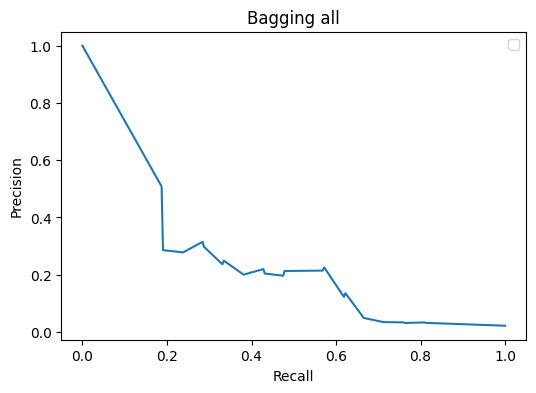

In [26]:
best_row = bagging_all_df.iloc[0]

match = None
for r in bagging_all_results:
    if r["label"] == best_row["label"]:
        match = r
        break

plot_smooth_pr(y_test, match["y_prob"], title="Bagging all")

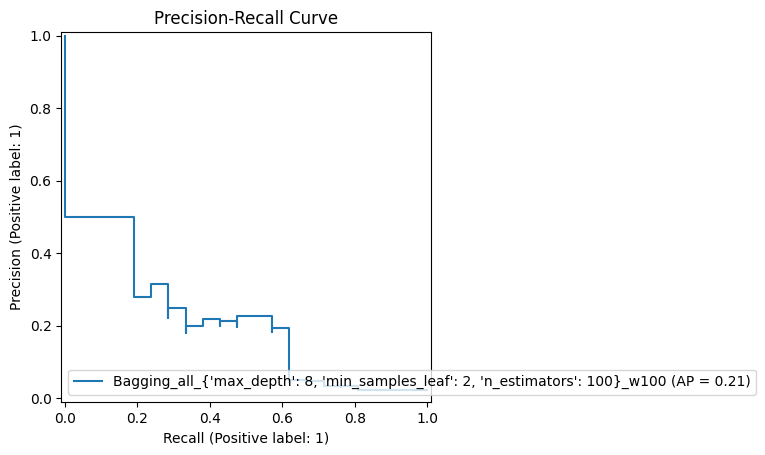

label                  Bagging_all_{'max_depth': 8, 'min_samples_leaf...
pos_weight                                                           100
best_threshold                                                     0.865
precision_at_target                                             0.214286
recall_at_target                                                0.571429
average_precision                                               0.208242
max_depth                                                            8.0
min_samples_leaf                                                       2
n_estimators                                                         100
Name: 45, dtype: object


In [27]:
best_row = bagging_all_df.iloc[0]

match = None
for r in bagging_all_results:
    if r["label"] == best_row["label"]:
        match = r
        break

PrecisionRecallDisplay.from_predictions(
    y_test,
    match["y_prob"],
    name=best_row["label"]
)
plt.title("Precision-Recall Curve")
plt.show()

print(best_row)

bagging_fs_df

/tmp/ipykernel_20510/2826035387.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


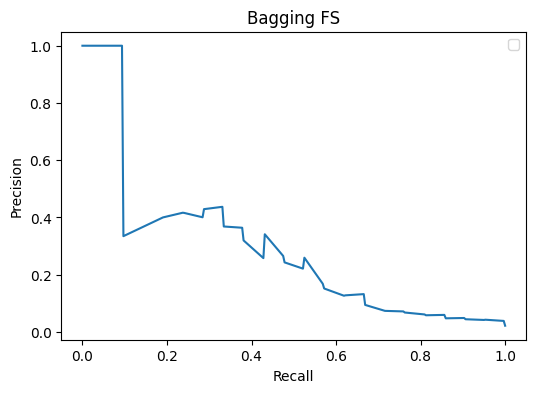

In [28]:
best_row = bagging_fs_df.iloc[0]

match = None
for r in bagging_fs_results:
    if r["label"] == best_row["label"]:
        match = r
        break

plot_smooth_pr(y_test, match["y_prob"], title="Bagging FS")

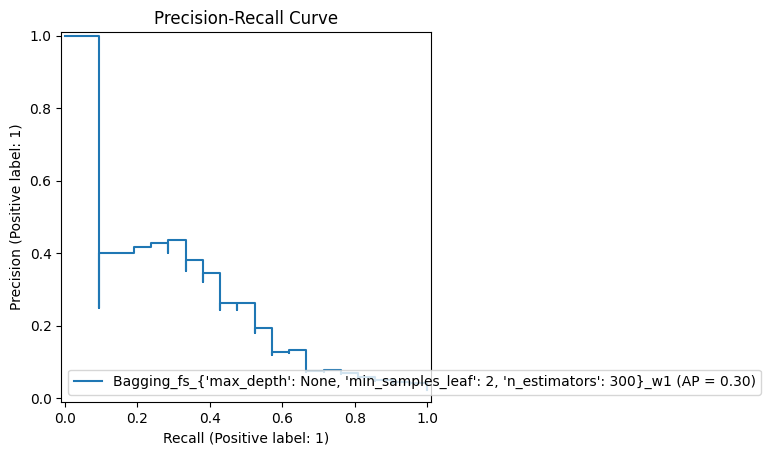

label                  Bagging_fs_{'max_depth': None, 'min_samples_le...
pos_weight                                                             1
best_threshold                                                     0.145
precision_at_target                                                 0.25
recall_at_target                                                 0.52381
average_precision                                               0.295534
max_depth                                                            NaN
min_samples_leaf                                                       2
n_estimators                                                         300
Name: 21, dtype: object


In [29]:
best_row = bagging_fs_df.iloc[0]

match = None
for r in bagging_fs_results:
    if r["label"] == best_row["label"]:
        match = r
        break

PrecisionRecallDisplay.from_predictions(
    y_test,
    match["y_prob"],
    name=best_row["label"]
)
plt.title("Precision-Recall Curve")
plt.show()

print(best_row)

mlp_all_df

/tmp/ipykernel_20510/2826035387.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


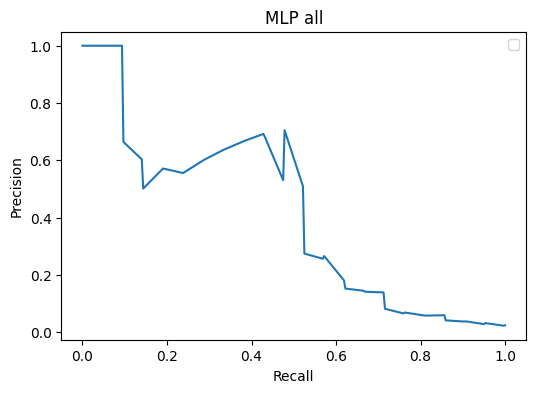

In [30]:
best_row = mlp_all_df.iloc[0]

match = None
for r in mlp_all_results:
    if r["label"] == best_row["label"]:
        match = r
        break

plot_smooth_pr(y_test, match["y_prob"], title="MLP all")

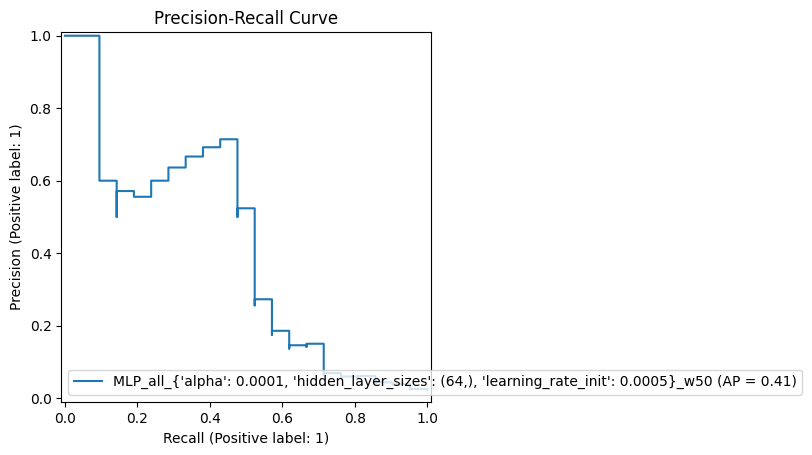

label                  MLP_all_{'alpha': 0.0001, 'hidden_layer_sizes'...
pos_weight                                                            50
best_threshold                                                      0.81
precision_at_target                                                  0.5
recall_at_target                                                 0.52381
average_precision                                               0.410062
alpha                                                             0.0001
hidden_layer_sizes                                                 (64,)
learning_rate_init                                                0.0005
Name: 9, dtype: object


In [31]:
best_row = mlp_all_df.iloc[0]

match = None
for r in mlp_all_results:
    if r["label"] == best_row["label"]:
        match = r
        break

PrecisionRecallDisplay.from_predictions(
    y_test,
    match["y_prob"],
    name=best_row["label"]
)
plt.title("Precision-Recall Curve")
plt.show()

print(best_row)

mlp_fs_df

/tmp/ipykernel_20510/2826035387.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


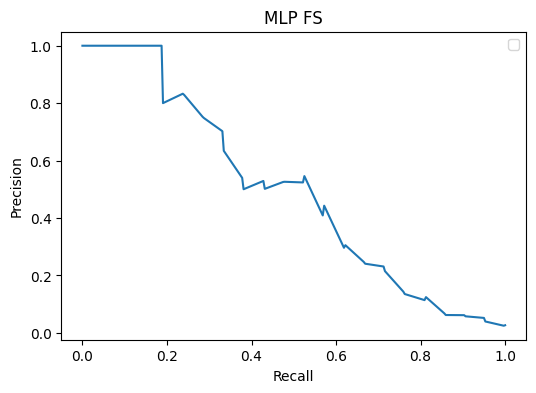

In [33]:
best_row = mlp_fs_df.iloc[0]

match = None
for r in mlp_fs_results:
    if r["label"] == best_row["label"]:
        match = r
        break

plot_smooth_pr(y_test, match["y_prob"], title="MLP FS")

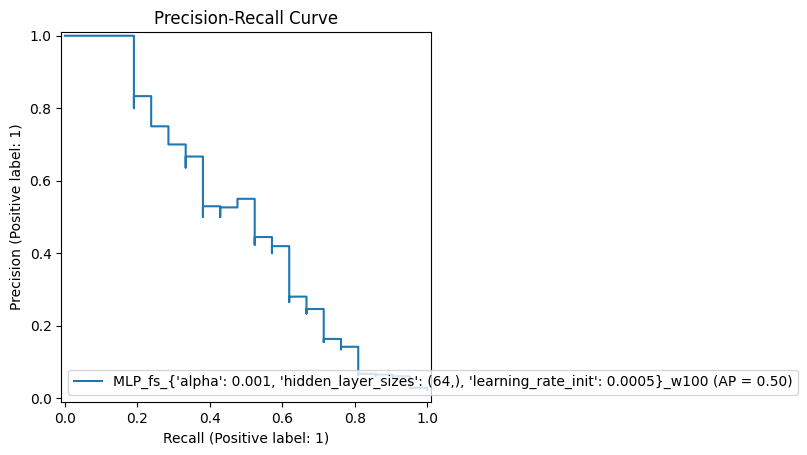

label                  MLP_fs_{'alpha': 0.001, 'hidden_layer_sizes': ...
pos_weight                                                           100
best_threshold                                                     0.885
precision_at_target                                                 0.55
recall_at_target                                                 0.52381
average_precision                                               0.498618
alpha                                                              0.001
hidden_layer_sizes                                                 (64,)
learning_rate_init                                                0.0005
Name: 52, dtype: object


In [34]:
best_row = mlp_fs_df.iloc[0]

match = None
for r in mlp_fs_results:
    if r["label"] == best_row["label"]:
        match = r
        break

PrecisionRecallDisplay.from_predictions(
    y_test,
    match["y_prob"],
    name=best_row["label"]
)
plt.title("Precision-Recall Curve")
plt.show()

print(best_row)

# Computational screening

files and important column names

In [35]:
import pandas as pd
import numpy as np

original_csv = "input_data.csv"              # training/original dataset with SMILES
screening_csv = "list_of_compounds_for_computational_screening.csv"      # new compounds to screen
known21_csv = "ResearchPaperPreds.csv"                  # 21 known senolytics from literature

smiles_col = "SMILES"
target_col = "senolytic"

read original input data and recreate the cleaned rows

In [36]:
orig = pd.read_csv(original_csv)

orig[smiles_col] = orig[smiles_col].astype(str).str.strip()

tmp = orig[target_col].astype(str).str.strip().str.lower()

y_map = tmp.map({
    "1": 1, "1.0": 1,
    "0": 0, "0.0": 0,
    "yes": 1, "no": 0,
    "true": 1, "false": 0,
    "senolytic": 1,
    "non-senolytic": 0
})

mask = y_map.notna()

orig_clean = orig.loc[mask].copy().reset_index(drop=True)
orig_clean[target_col] = y_map.loc[mask].astype(int).values

print(orig_clean.shape)
orig_clean[[smiles_col, target_col]].head()

(4866, 203)


,SMILES,senolytic
0,c12/N=C(\NC(c1nn[nH]2)=O)/N,0
1,N1C(NC(C1=O)NC(=O)N)=O,0
2,c1(S(=O)(=O)N)sc(nn1)NC(=O)C,0
3,C(NC(=N)N)(=N)N(C)C,0
4,[N+]1(C(c2c(cc(c(c2)OC)OC)CC1)Cc1cc(c(cc1)OC)O...,0


attach SMILES back to df_norm and df_selected

In [37]:
df_norm = df_norm.reset_index(drop=True).copy()
df_selected = df_selected.reset_index(drop=True).copy()

print("orig_clean rows:", len(orig_clean))
print("df_norm rows:", len(df_norm))
print("df_selected rows:", len(df_selected))

assert len(orig_clean) == len(df_norm), "orig_clean and df_norm row counts do not match"
assert len(orig_clean) == len(df_selected), "orig_clean and df_selected row counts do not match"

df_norm[smiles_col] = orig_clean[smiles_col]
df_selected[smiles_col] = orig_clean[smiles_col]

orig_clean rows: 4866
df_norm rows: 4866
df_selected rows: 4866


get the feature columns for the 2 model types

In [38]:
features_all = [c for c in df_norm.columns if c not in [target_col, smiles_col]]
features_fs = [c for c in df_selected.columns if c not in [target_col, smiles_col]]

print("All-feature model uses:", len(features_all), "features")
print("FS model uses:", len(features_fs), "features")

All-feature model uses: 200 features
FS model uses: 17 features


read the screening dataset

In [39]:
screen = pd.read_csv(screening_csv)
screen[smiles_col] = screen[smiles_col].astype(str).str.strip()

print(screen.shape)
screen.head()

(4340, 203)


,Name,Library,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
0,(-)-Arctigenin,Selleck,COC1=C(O)C=CC(=C1)CC2C(COC2=O)CC3=CC=C(OC)C(=C...,1.763934,816.314286,19.388541,15.728578,15.728578,13.049575,8.787575,...,0,0,0,0,0,0,0,0,0,0.753438
1,(-)-Blebbistatin,Targetmol 3338,Cc1ccc2N=C3N(CC[C@@]3(O)C(=O)c2c1)c1ccccc1,1.880486,797.989385,15.319626,12.282905,12.282905,10.593172,7.390657,...,0,0,0,0,0,0,0,0,0,0.879020
2,(-)-Borneol,Selleck,CC1(C)C2CCC1(C)C(O)C2,2.396255,185.311799,8.276021,7.723234,7.723234,4.982999,4.663847,...,0,0,0,0,0,0,0,0,0,0.566800
3,(-)-Cotinine,Targetmol 3338,CN1[C@@H](CCC1=O)c1cccnc1,2.236360,309.960601,9.259149,7.603640,7.603640,6.287694,4.444035,...,0,0,0,0,0,0,0,0,0,0.647201
4,(-)-Epicatechin gallate,Selleck,OC1=CC2=C(CC(OC(=O)C3=CC(=C(O)C(=C3)O)O)C(O2)C...,1.721352,1196.568791,23.153972,16.258499,16.258499,15.133938,9.330270,...,0,0,0,0,0,0,0,0,0,0.235487


create the 2 screening datasets

In [40]:
missing_all = [c for c in features_all if c not in screen.columns]
missing_fs = [c for c in features_fs if c not in screen.columns]

print("Missing columns for ALL model:", missing_all)
print("Missing columns for FS model:", missing_fs)

Missing columns for ALL model: []
Missing columns for FS model: []


In [41]:
screen_all = screen[[smiles_col] + features_all].copy()
screen_fs = screen[[smiles_col] + features_fs].copy()

print(screen_all.shape)
print(screen_fs.shape)

(4340, 201)
(4340, 18)


clean the 2 screening datasets

In [42]:
def clean_screen_df(df, smiles_col="SMILES"):
    df = df.copy()

    feature_cols = [c for c in df.columns if c != smiles_col]

    df[feature_cols] = df[feature_cols].replace("?", np.nan)

    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

screen_all = clean_screen_df(screen_all, smiles_col=smiles_col)
screen_fs = clean_screen_df(screen_fs, smiles_col=smiles_col)

print(screen_all.dtypes.head())
print(screen_fs.dtypes.head())

SMILES       object
BalabanJ    float64
BertzCT     float64
Chi0        float64
Chi0n       float64
dtype: object
SMILES                      object
EState_VSA3                float64
EState_VSA7                float64
NumSaturatedCarbocycles      int64
PEOE_VSA7                  float64
dtype: object


separate SMILES and X matrices

In [43]:
screen_all_smiles = screen_all[smiles_col].copy()
screen_fs_smiles = screen_fs[smiles_col].copy()

X_screen_all = screen_all.drop(columns=[smiles_col]).copy()
X_screen_fs = screen_fs.drop(columns=[smiles_col]).copy()

print(X_screen_all.shape)
print(X_screen_fs.shape)

(4340, 200)
(4340, 17)


run screening with the 4 trained models

## best_config_1

In [47]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight

target_col = "senolytic"
smiles_col = "SMILES"
known21_csv = "ResearchPaperPreds.csv"

# 1) full training matrices
X_all_full = df_norm.drop(columns=[target_col, smiles_col], errors="ignore").copy()
X_fs_full  = df_selected.drop(columns=[target_col, smiles_col], errors="ignore").copy()
y_full = df_norm[target_col].astype(int).copy()

# 2) clean + align screening matrices
def fix_screen_matrix(X, ref_cols):
    X = X.copy()
    X = X[ref_cols]
    X = X.replace("?", np.nan)

    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan)
    limit = np.finfo(np.float32).max
    X = X.mask(np.abs(X) > limit, np.nan)

    return X

X_screen_all = fix_screen_matrix(X_screen_all, X_all_full.columns)
X_screen_fs  = fix_screen_matrix(X_screen_fs, X_fs_full.columns)

# 3) build final models using the best settings from your notebook
best_bagging_all_model = make_bagging_model(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=2
)

best_bagging_fs_model = make_bagging_model(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2
)

best_mlp_all_model = make_mlp_model(
    hidden_layer_sizes=(64,),
    alpha=0.0001,
    learning_rate_init=0.0005
)

best_mlp_fs_model = make_mlp_model(
    hidden_layer_sizes=(64,),
    alpha=0.0010,
    learning_rate_init=0.0005
)

# 4) fit final models on full labeled data
w_bag_all = compute_sample_weight(class_weight={0: 1, 1: 2}, y=y_full)
w_bag_fs  = compute_sample_weight(class_weight={0: 1, 1: 2}, y=y_full)
w_mlp_all = compute_sample_weight(class_weight={0: 1, 1: 8}, y=y_full)
w_mlp_fs  = compute_sample_weight(class_weight={0: 1, 1: 15}, y=y_full)

best_bagging_all_model.fit(X_all_full, y_full, model__sample_weight=w_bag_all)
best_bagging_fs_model.fit(X_fs_full, y_full, model__sample_weight=w_bag_fs)
best_mlp_all_model.fit(X_all_full, y_full, model__sample_weight=w_mlp_all)
best_mlp_fs_model.fit(X_fs_full, y_full, model__sample_weight=w_mlp_fs)
# #---------------DYNAMIC RETRIEVAL FIX-------------------------------------
# def get_best_saved_model(results_list, results_df):
#     best_label = results_df.iloc[0]["label"]
#     for r in results_list:
#         if r["label"] == best_label:
#             return r["model"]
#     raise ValueError("Best model not found")

# best_bagging_all_model = get_best_saved_model(bagging_all_results, bagging_all_df)
# best_bagging_fs_model  = get_best_saved_model(bagging_fs_results, bagging_fs_df)
# best_mlp_all_model     = get_best_saved_model(mlp_all_results, mlp_all_df)
# best_mlp_fs_model      = get_best_saved_model(mlp_fs_results, mlp_fs_df)
# #--------------------------------------------------------------------------

# 5) screening predictions: 0/1 only
screen_results = pd.DataFrame({
    smiles_col: screen_all_smiles.astype(str).str.strip()
})

screen_results["bagging_all_pred"] = best_bagging_all_model.predict(X_screen_all)
screen_results["bagging_fs_pred"]  = best_bagging_fs_model.predict(X_screen_fs)
screen_results["mlp_all_pred"]     = best_mlp_all_model.predict(X_screen_all)
screen_results["mlp_fs_pred"]      = best_mlp_fs_model.predict(X_screen_fs)

# 6) compare with known 21 by SMILES
known21 = pd.read_csv(known21_csv)
known21[smiles_col] = known21[smiles_col].astype(str).str.strip()

screen_results["known21_hit"] = screen_results[smiles_col].isin(known21[smiles_col]).astype(int)

known21_results = screen_results[screen_results["known21_hit"] == 1].copy()

summary_hits = pd.DataFrame({
    "model": ["bagging_all", "bagging_fs", "mlp_all", "mlp_fs"],
    "hits_found_among_known21": [
        int(known21_results["bagging_all_pred"].sum()),
        int(known21_results["bagging_fs_pred"].sum()),
        int(known21_results["mlp_all_pred"].sum()),
        int(known21_results["mlp_fs_pred"].sum())
    ]
})

summary_hits["out_of_21"] = len(known21)
summary_hits["recall_on_known21"] = summary_hits["hits_found_among_known21"] / len(known21)

# 7) EXTRA: check the 3 special compounds by exact SMILES
special3 = pd.DataFrame([
    {
        "special3_name": "Ginkgetin",
        smiles_col: "COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O)cc(O)c2c1oc(cc2=O)-c1ccc(O)cc1"
    },
    {
        "special3_name": "Oleandrin",
        smiles_col: "CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H]4[C@@H]3CC[C@]3(C)[C@H]([C@H](C[C@]43O)OC(C)=O)C3=CC(=O)OC3)C2)O[C@@H](C)[C@@H]1O"
    },
    {
        "special3_name": "Periplocin",
        smiles_col: "CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(C)[C@H](CC[C@]5(O)[C@@H]4CC[C@]3(O)C2)C2=CC(=O)OC2)O[C@H](C)[C@H]1O[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@H]1O"
    }
])

special3[smiles_col] = special3[smiles_col].astype(str).str.strip()

screen_results = screen_results.merge(special3, on=smiles_col, how="left")
screen_results["is_special3"] = screen_results["special3_name"].notna().astype(int)

special3_results = screen_results[screen_results["is_special3"] == 1].copy()

special3_summary = pd.DataFrame({
    "model": ["bagging_all", "bagging_fs", "mlp_all", "mlp_fs"],
    "predicted_positive_among_special3": [
        int(special3_results["bagging_all_pred"].sum()),
        int(special3_results["bagging_fs_pred"].sum()),
        int(special3_results["mlp_all_pred"].sum()),
        int(special3_results["mlp_fs_pred"].sum())
    ]
})

print("Known compounds found in screening set:", int(screen_results["known21_hit"].sum()))
print()
print(summary_hits)
print()
print("Special 3 compounds found in screening set:", int(screen_results["is_special3"].sum()))
print()
print(special3_results[[
    "special3_name",
    smiles_col,
    "bagging_all_pred",
    "bagging_fs_pred",
    "mlp_all_pred",
    "mlp_fs_pred"
]])
print()
print(special3_summary)

Known compounds found in screening set: 21

         model  hits_found_among_known21  out_of_21  recall_on_known21
0  bagging_all                         1         21           0.047619
1   bagging_fs                         3         21           0.142857
2      mlp_all                        21         21           1.000000
3       mlp_fs                        16         21           0.761905

Special 3 compounds found in screening set: 3

     special3_name                                             SMILES  \
1800     Ginkgetin  COc1cc(O)c2c(c1)oc(cc2=O)-c1ccc(OC)c(c1)-c1c(O...   
2911     Oleandrin  CO[C@H]1C[C@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H...   
3078    Periplocin  CO[C@H]1C[C@H](O[C@H]2CC[C@]3(C)[C@H]4CC[C@]5(...   

      bagging_all_pred  bagging_fs_pred  mlp_all_pred  mlp_fs_pred  
1800                 0                0             1            1  
2911                 0                0             1            1  
3078                 0                0             1